In [1]:
# Cell 1: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT/'figures'/'figures_Markov'/'figures_QuartaryModel'
RESULTS = PROJ_ROOT/'results'/'results_Markov'/'results_QuartaryModel'


In [2]:
# Cell 2: globals settings

EPS = 0.49
N = 50000
Y = 20
SEED = 63

rng = np.random.default_rng(SEED)


In [3]:
# Cell 3: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

In [4]:
# cell 4: build empirical w/ log prod and transitions


df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())
working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)
working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)
working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]
is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)
working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["log_pubs_adj", "log_pubs_next"]).copy())

print("Rows in orig df:", len(working_df))
print("Rows w valid one-year trans:", len(working_df_fit))
print()
print(working_df_fit[["log_pubs_adj", "log_pubs_next", "log_delta"]].describe())

Rows in orig df: 54948
Rows w valid one-year trans: 34701

       log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000
mean       1.442084       1.448262      0.006178
std        1.131298       1.123265      1.057639
min       -0.713350      -0.713350     -5.028100
25%        0.924939       0.924939     -0.509761
50%        1.661082       1.661082     -0.026502
75%        2.251545       2.251545      0.523108
max        4.396630       4.396630      4.138016


In [5]:
# Cell 5: build none/low/regular/high states

df = working_df.copy()
df = df[df["CareerAge"].between(0, Y)].copy()

id_col = "dblp_id"
age_col = "CareerAge"
prod_col = "pubs_adj"

positive_pubs = df.loc[df[prod_col] > 0, prod_col]
p25, p50, p75 = positive_pubs.quantile([0.25, 0.50, 0.75])

state_cutpoints = pd.Series({
    "p30_positive_pubs": p25,
    "p60_positive_pubs": p50,
    "p90_positive_pubs": p75,
})

def assign_productivity_state(x):
    if pd.isna(x):
        return np.nan
    elif x <= 0:
        return 0
    elif x <= p25:
        return 1
    elif x <= p50:
        return 2
    else:
        return 3

df["state"] = df[prod_col].apply(assign_productivity_state).astype(int)

state_labels = {
    0: "None",
    1: "Low",
    2: "Regular",
    3: "High",
}

state_order = [0, 1, 2, 3]
n_states = len(state_order)


In [6]:
# Cell 6: trans counts n probs

df = df.sort_values([id_col, age_col]).copy()

df["next_state"] = df.groupby(id_col)["state"].shift(-1)
df["next_age"] = df.groupby(id_col)[age_col].shift(-1)

trans = df[df["next_age"] == df[age_col] + 1].copy()

trans["state"] = trans["state"].astype(int)
trans["next_state"] = trans["next_state"].astype(int)

def transition_counts_and_probs(g):
    counts = pd.crosstab(g["state"], g["next_state"])
    counts = counts.reindex(index=state_order, columns=state_order, fill_value=0)
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return counts, probs

global_counts, global_P = transition_counts_and_probs(trans)

print("Transition counts:")
print(global_counts.rename(index=state_labels, columns=state_labels))

print("\nTransition probabilities:")
print(global_P.rename(index=state_labels, columns=state_labels).round(3))


Transition counts:
next_state  None   Low  Regular   High
state                                 
None        2318  1478      878    705
Low         1313  2570     1696   1352
Regular      855  1739     2159   2564
High         655  1403     2578  10438

Transition probabilities:
next_state   None    Low  Regular   High
state                                   
None        0.431  0.275    0.163  0.131
Low         0.189  0.371    0.245  0.195
Regular     0.117  0.238    0.295  0.350
High        0.043  0.093    0.171  0.692


In [7]:
# Cell 7: stagewise P matrices

stage_order = ["0-4", "5-7", "8-13", "14-20"]

def assign_career_stage(year):
    if 0 <= year <= 4:
        return "0-4"
    elif 5 <= year <= 7:
        return "5-7"
    elif 8 <= year <= 13:
        return "8-13"
    elif 14 <= year <= 20:
        return "14-20"
    else:
        return np.nan
trans["stage"] = trans[age_col].apply(assign_career_stage)


stage_counts = {}
stage_P = {}

for stage in stage_order:
    g = trans[trans["stage"] == stage]

    counts, probs = transition_counts_and_probs(g)

    stage_counts[stage] = counts
    stage_P[stage] = probs

    print(f"{stage} counts:")
    print(counts.rename(index=state_labels, columns=state_labels))

    print(f"{stage} P matrix:")
    print(probs.rename(index=state_labels, columns=state_labels).round(3))
    print()


0-4 counts:
next_state  None  Low  Regular  High
state                               
None         624  412      342   332
Low          349  803      617   585
Regular      303  481      664   979
High         258  385      679  3105
0-4 P matrix:
next_state   None    Low  Regular   High
state                                   
None        0.365  0.241    0.200  0.194
Low         0.148  0.341    0.262  0.249
Regular     0.125  0.198    0.274  0.403
High        0.058  0.087    0.153  0.701

5-7 counts:
next_state  None  Low  Regular  High
state                               
None         324  190      132   127
Low          190  341      248   194
Regular      135  299      410   477
High         144  291      603  2296
5-7 P matrix:
next_state   None    Low  Regular   High
state                                   
None        0.419  0.246    0.171  0.164
Low         0.195  0.350    0.255  0.199
Regular     0.102  0.226    0.310  0.361
High        0.043  0.087    0.181  0.689

8-13 count

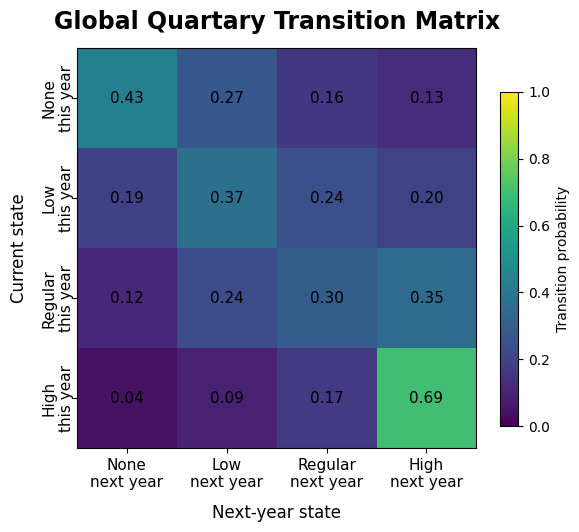

In [8]:
# Cell 8: global none/low/regular/high transition heatmap

def plot_transition_heatmap(P, title):
    fig, ax = plt.subplots(figsize=(6.2, 5.4))

    mat = P.values.astype(float)

    im = ax.imshow(mat, vmin=0, vmax=1, aspect="equal")

    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))

    ax.set_xticklabels(
        [f"{state_labels[s]}\nnext year" for s in state_order],
        fontsize=11
    )

    ax.set_yticklabels(
        [f"{state_labels[s]}\nthis year" for s in state_order],
        fontsize=11,
        rotation=90,
        va="center",
        ha="center",
        rotation_mode="anchor"
    )

    ax.tick_params(axis="y", pad=10)
    for label in ax.get_yticklabels():
        x, y = label.get_position()
        label.set_y(y - 0.04) 

    for i in range(n_states):
        for j in range(n_states):
            val = mat[i, j]
            label = "—" if np.isnan(val) else f"{val:.2f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=11)

    ax.set_title(title, fontsize=17, fontweight="bold", pad=14)
    ax.set_xlabel("Next-year state", fontsize=12, labelpad=10)
    ax.set_ylabel("Current state", fontsize=12, labelpad=10)

    fig.subplots_adjust(left=0.18, right=0.84, top=0.88, bottom=0.14)

    cbar_ax = fig.add_axes([0.87, 0.18, 0.03, 0.62])
    fig.colorbar(im, cax=cbar_ax, label="Transition probability")

    plt.savefig(FIGURES / "quartaryModel_globalTransMatrix.png", dpi=300, bbox_inches="tight")

    plt.show()


plot_transition_heatmap(global_P, "Global Quartary Transition Matrix")


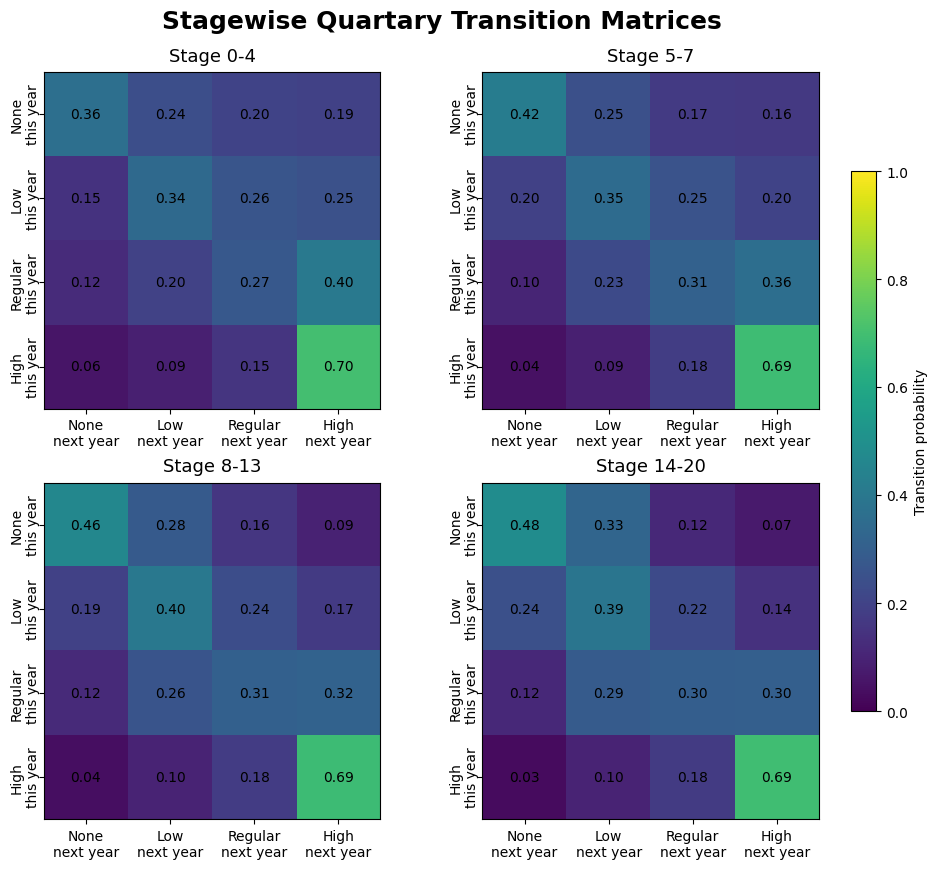

In [9]:
# Cell 9: stagewise none/low/regular/high transition heatmaps

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 9),
    gridspec_kw={"wspace": 0.15, "hspace": 0.22})

axes_flat = axes.ravel()

for ax, stage in zip(axes_flat, stage_order):
    P_stage = stage_P[stage]
    mat = P_stage.values.astype(float)

    im = ax.imshow(mat, vmin=0, vmax=1, aspect="equal")

    ax.set_title(f"Stage {stage}", fontsize=13, pad=8)

    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))

    ax.set_xticklabels(
        [f"{state_labels[s]}\nnext year" for s in state_order],
        fontsize=10)

    ax.set_yticklabels(
        [f"{state_labels[s]}\nthis year" for s in state_order],
        fontsize=10,
        rotation=90,
        va="center",
        ha="center",
        rotation_mode="anchor")

    ax.tick_params(axis="y", pad=10)

    for label in ax.get_yticklabels():
        x, y = label.get_position()
        label.set_y(y - 1)

    for i in range(n_states):
        for j in range(n_states):
            val = mat[i, j]
            label = "—" if np.isnan(val) else f"{val:.2f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=10)

for ax in axes_flat[len(stage_order):]:
    ax.axis("off")

fig.suptitle("Stagewise Quartary Transition Matrices",fontsize=18,fontweight="bold",x=0.5,y=0.98)

fig.subplots_adjust(left=0.08,right=0.90,top=0.91,bottom=0.08,wspace=0.12,hspace=0.28)

cbar_ax = fig.add_axes([0.91, 0.20, 0.025, 0.60])
fig.colorbar(im, cax=cbar_ax, label="Transition probability")

plt.savefig(FIGURES / "quartaryModel_stageTransMatrices.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
# Cell 10: trans summary

summary_rows = []

state_column_names = {
    0: "none",
    1: "low",
    2: "regular", 3: "high",}

for stage in stage_order:
    P_stage = stage_P[stage]

    row = {"stage": stage}

    for from_state in state_order:
        for to_state in state_order:
            from_name = state_column_names[from_state]
            to_name = state_column_names[to_state]
            row[f"P_{from_name}_to_{to_name}"] = P_stage.loc[from_state, to_state]

    summary_rows.append(row)

stage_transition_summary = pd.DataFrame(summary_rows).round(3)

display(stage_transition_summary)


,stage,P_none_to_none,P_none_to_low,P_none_to_regular,P_none_to_high,P_low_to_none,P_low_to_low,P_low_to_regular,P_low_to_high,P_regular_to_none,P_regular_to_low,P_regular_to_regular,P_regular_to_high,P_high_to_none,P_high_to_low,P_high_to_regular,P_high_to_high
0,0-4,0.365,0.241,0.200,0.194,0.148,0.341,0.262,0.249,0.125,0.198,0.274,0.403,0.058,0.087,0.153,0.701
1,5-7,0.419,0.246,0.171,0.164,0.195,0.350,0.255,0.199,0.102,0.226,0.310,0.361,0.043,0.087,0.181,0.689
2,8-13,0.463,0.284,0.159,0.095,0.194,0.400,0.236,0.170,0.118,0.258,0.308,0.316,0.037,0.098,0.178,0.686
3,14-20,0.485,0.325,0.117,0.073,0.243,0.390,0.223,0.143,0.115,0.286,0.298,0.301,0.030,0.101,0.175,0.693


In [11]:
out_path = RESULTS / "quartaryModel.csv"
stage_transition_summary.to_csv(out_path, index=False)
